# Predicción de riesgo de accidente cerebrovascular
## Regresión Lineal Múltiple – Versión básica (corregida)

Objetivo: predecir `Stroke_Risk_Score` a partir de las características del dataset.

Se implementa:
- Imputación de datos faltantes
- Codificación ordinal y one-hot
- Normalización
- Descenso de gradiente desde cero
- Predicción sobre registros del dataset

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer

## 1. Carga y exploración de datos

In [157]:
# Cargar el dataset (debe estar en la misma carpeta que el notebook)
df = pd.read_csv('stroke_risk_prediction_dataset.csv')

print('Forma del dataset:', df.shape)
df.head()

Forma del dataset: (50000, 40)


,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,...,Medication_Adherence,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Work_Type,Residence_Type,Air_Pollution_Exposure,Stroke_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Stroke_Risk
0,1,80.0,Male,China,145.2,69.3,32.9,112,82,109,...,Excellent,NaN,79.0,Retired,Urban,High,47,Exercise Regularly,Yes,Moderate
1,2,37.0,Female,United Kingdom,188.6,110.8,31.1,137,76,59,...,Average,0.6,48.0,Student,Rural,Medium,40,Improve Diet Quality,Yes,Moderate
2,3,85.0,Female,Germany,175.5,103.7,33.7,108,105,89,...,Poor,1.7,114.0,Private,Rural,Medium,76,Monitor Blood Glucose Daily,Yes,High
3,4,44.0,Other,Brazil,161.3,50.2,19.3,126,73,88,...,Poor,1.5,101.0,Retired,Rural,Low,40,Exercise Regularly,Yes,Moderate
4,5,52.0,Female,United States,162.8,103.6,39.1,115,60,70,...,Average,7.1,55.0,Government,Rural,Medium,38,Monitor Blood Pressure,Yes,Moderate


In [158]:
print('Columnas disponibles:')
print(df.columns.tolist())
print()
df.info()

Columnas disponibles:
['Patient_ID', 'Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg', 'BMI', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Heart_Rate', 'Blood_Glucose', 'HbA1c', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Sleep_Hours', 'Stress_Level', 'Diet_Quality', 'Family_History_Stroke', 'Family_History_Heart_Disease', 'Diabetes', 'Hypertension', 'Heart_Disease', 'Previous_TIA', 'Atrial_Fibrillation', 'Chronic_Kidney_Disease', 'Medication_Adherence', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Work_Type', 'Residence_Type', 'Air_Pollution_Exposure', 'Stroke_Risk_Score', 'AI_Health_Recommendation', 'Doctor_Consultation_Needed', 'Stroke_Risk']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID   

## 2. Selección de variables

La variable objetivo es `Stroke_Risk_Score`.

Se excluyen:
- `Patient_ID` (identificador)
- `AI_Health_Recommendation` (texto)
- `Doctor_Consultation_Needed` (derivada)
- `Stroke_Risk` (versión categórica del objetivo)

In [159]:
columnas_excluir = [
    'Patient_ID',
    'Stroke_Risk_Score',
    'AI_Health_Recommendation',
    'Doctor_Consultation_Needed',
    'Stroke_Risk'
]

variables_x = [col for col in df.columns if col not in columnas_excluir]

X = df[variables_x].copy()
y = df['Stroke_Risk_Score'].copy()

print('Número de variables predictoras:', len(variables_x))
print('Variable objetivo: Stroke_Risk_Score')
print('\nTipos de variables:')
print(X.dtypes.value_counts())
print('\nValores faltantes por columna:')
print(X.isnull().sum()[X.isnull().sum() > 0])

Número de variables predictoras: 35
Variable objetivo: Stroke_Risk_Score

Tipos de variables:
object     19
float64    13
int64       3
Name: count, dtype: int64

Valores faltantes por columna:
Age                         219
Height_cm                  1525
Weight_kg                  1523
Blood_Glucose               960
HbA1c                      1006
Total_Cholesterol          1004
HDL                        1021
LDL                        1050
Triglycerides              1032
Sleep_Hours                1026
Medication_Adherence       1051
Exercise_Hours_Per_Week    1054
Daily_Walking_Minutes      1051
dtype: int64


## 3. Imputación de datos faltantes

En lugar de eliminar registros, se completan los valores faltantes:
- **Numéricas**: mediana (robusta a outliers)
- **Categóricas**: moda (valor más frecuente)

In [160]:
columnas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
columnas_categoricas = X.select_dtypes(include=['object']).columns.tolist()

print('Variables numéricas:', len(columnas_numericas))
print('Variables categóricas:', len(columnas_categoricas))

# Imputación numéricas (mediana)
imputer_num = SimpleImputer(strategy='median')
X[columnas_numericas] = imputer_num.fit_transform(X[columnas_numericas])

# NO imputar categóricas todavía - primero haremos ordinal encoding
print('\nDatos faltantes en numéricas después de imputación:', X[columnas_numericas].isnull().sum().sum())
print('Datos faltantes en categóricas (antes de encoding):', X[columnas_categoricas].isnull().sum().sum())

Variables numéricas: 16
Variables categóricas: 19

Datos faltantes en numéricas después de imputación: 0
Datos faltantes en categóricas (antes de encoding): 1051


## 4. Codificación de variables categóricas

### 4.1 Ordinal Encoding
Variables con orden natural (ej. Low < Medium < High).

In [161]:
# Verificar valores únicos en las columnas ordinales (valores originales del CSV)
print('Valores únicos en columnas ordinales (originales):')
for columna in ['Stress_Level', 'Diet_Quality', 'Physical_Activity_Level', 
                'Medication_Adherence', 'Alcohol_Consumption', 'Smoking_Status', 
                'Air_Pollution_Exposure']:
    if columna in X.columns:
        valores_unicos = X[columna].dropna().unique()
        print(f'{columna}: {sorted(valores_unicos)}')

print('\n' + '='*60 + '\n')

# Mapeos ordinales CORREGIDOS según los valores reales del CSV
mapeos_ordinales = {
    'Stress_Level': {'Low': 0, 'Moderate': 1, 'High': 2},
    'Diet_Quality': {'Poor': 0, 'Average': 1, 'Healthy': 2},
    'Physical_Activity_Level': {'Low': 0, 'Moderate': 1, 'High': 2},
    'Medication_Adherence': {'Poor': 0, 'Average': 1, 'Excellent': 2},
    'Alcohol_Consumption': {'Never': 0, 'Occasionally': 1, 'Frequently': 2},
    'Smoking_Status': {'Never': 0, 'Former': 1, 'Current': 2},
    'Air_Pollution_Exposure': {'Low': 0, 'Medium': 1, 'High': 2}
}

for columna, mapeo in mapeos_ordinales.items():
    if columna in X.columns:
        X[columna] = X[columna].map(mapeo)

print('Ordinal encoding aplicado a:', list(mapeos_ordinales.keys()))
print('\nValores nulos después de ordinal encoding:', X[list(mapeos_ordinales.keys())].isnull().sum().sum())

# Ahora imputar los valores nulos que quedaron después del encoding
columnas_ordinales = list(mapeos_ordinales.keys())
imputer_ord = SimpleImputer(strategy='most_frequent')
X[columnas_ordinales] = imputer_ord.fit_transform(X[columnas_ordinales])

print('Valores nulos después de imputar ordinales:', X[columnas_ordinales].isnull().sum().sum())

print('\n' + '='*60 + '\n')

# Codificar variables binarias (Yes/No -> 1/0)
columnas_binarias = [
    'Family_History_Stroke', 'Family_History_Heart_Disease', 'Diabetes',
    'Hypertension', 'Heart_Disease', 'Previous_TIA', 'Atrial_Fibrillation',
    'Chronic_Kidney_Disease'
]

print('Columnas binarias (Yes/No):', columnas_binarias)
for columna in columnas_binarias:
    if columna in X.columns:
        X[columna] = X[columna].map({'Yes': 1, 'No': 0})

print('Codificación binaria aplicada (Yes=1, No=0)')

Valores únicos en columnas ordinales (originales):
Stress_Level: ['High', 'Low', 'Moderate']
Diet_Quality: ['Average', 'Healthy', 'Poor']
Physical_Activity_Level: ['High', 'Low', 'Moderate']
Medication_Adherence: ['Average', 'Excellent', 'Poor']
Alcohol_Consumption: ['Frequently', 'Never', 'Occasionally']
Smoking_Status: ['Current', 'Former', 'Never']
Air_Pollution_Exposure: ['High', 'Low', 'Medium']


Ordinal encoding aplicado a: ['Stress_Level', 'Diet_Quality', 'Physical_Activity_Level', 'Medication_Adherence', 'Alcohol_Consumption', 'Smoking_Status', 'Air_Pollution_Exposure']

Valores nulos después de ordinal encoding: 1051
Valores nulos después de imputar ordinales: 0


Columnas binarias (Yes/No): ['Family_History_Stroke', 'Family_History_Heart_Disease', 'Diabetes', 'Hypertension', 'Heart_Disease', 'Previous_TIA', 'Atrial_Fibrillation', 'Chronic_Kidney_Disease']
Codificación binaria aplicada (Yes=1, No=0)


### 4.2 One-Hot Encoding
Variables sin orden natural (Gender, Country, Work_Type, etc.).

In [162]:
# Columnas categóricas restantes para one-hot encoding (excluyendo binarias)
columnas_onehot = X.select_dtypes(include=['object']).columns.tolist()
print('Columnas para one-hot encoding:', columnas_onehot)

# Verificar valores únicos en estas columnas
print('\nValores únicos en columnas one-hot:')
for col in columnas_onehot:
    print(f'{col}: {X[col].unique()}')

X = pd.get_dummies(X, columns=columnas_onehot, drop_first=True)

print('\nDimensiones después de one-hot encoding:', X.shape)
print('Tipos de datos:')
print(X.dtypes.value_counts())

Columnas para one-hot encoding: ['Gender', 'Country', 'Work_Type', 'Residence_Type']

Valores únicos en columnas one-hot:
Gender: ['Male' 'Female' 'Other']
Country: ['China' 'United Kingdom' 'Germany' 'Brazil' 'United States' 'Singapore'
 'UAE' 'India' 'South Korea' 'Italy' 'South Africa' 'Russia' 'Malaysia'
 'Turkey' 'Japan' 'Canada' 'Pakistan' 'Spain' 'Bangladesh' 'Indonesia'
 'Australia' 'France' 'Nigeria' 'Mexico' 'Saudi Arabia']
Work_Type: ['Retired' 'Student' 'Private' 'Government' 'Self-Employed']
Residence_Type: ['Urban' 'Rural']

Dimensiones después de one-hot encoding: (50000, 62)
Tipos de datos:
bool       31
float64    23
int64       8
Name: count, dtype: int64


## 5. Normalización y matriz de diseño

Se estandarizan las variables (media 0, desviación 1) y se agrega la columna de unos para el intercepto ($\theta_0$).

In [163]:
# Guardar nombres de columnas (sin el intercepto) para predicciones posteriores
nombres_columnas = X.columns.tolist()

# Media y desviación (se usan también en predicción)
media = X.mean()
desviacion = X.std()
desviacion = desviacion.replace(0, 1)  # evitar división por cero

X_norm = (X - media) / desviacion

# Imprimir las primeras 10 filas del dataset normalizado
print('Primeras 10 filas del dataset normalizado:')
print(X_norm.head(10))

# Convertir a arrays numpy
X_mat = X_norm.to_numpy(dtype=float)
y_mat = y.to_numpy(dtype=float).reshape(-1, 1)

# Agregar columna de unos para theta_0
X_mat = np.c_[np.ones((X_mat.shape[0], 1)), X_mat]

print('\nDimensión de X (con intercepto):', X_mat.shape)
print('Dimensión de y:', y_mat.shape)
print('Número de características (sin intercepto):', len(nombres_columnas))

Primeras 10 filas del dataset normalizado:
        Age  Height_cm  Weight_kg       BMI  Blood_Pressure_Systolic  \
0  1.241226  -1.747641  -0.752671  0.194900                -1.123492   
1 -0.803982   1.295417   0.963023  0.019368                 0.094443   
2  1.479041   0.376890   0.669495  0.272914                -1.318361   
3 -0.471041  -0.618765  -1.542304 -1.131339                -0.441448   
4 -0.090537  -0.513590   0.665361  0.799509                -0.977339   
5  1.241226  -0.436462   0.012156  0.175397                 1.409811   
6 -0.994234  -0.275194  -1.186763 -0.936304                 0.679051   
7 -0.566167   1.028974   1.641033  0.614226                -0.733753   
8 -0.518604  -1.509245   0.012156  0.867771                -0.149144   
9 -0.233226   0.503100   1.438457  0.780006                 0.679051   

   Blood_Pressure_Diastolic  Heart_Rate  Blood_Glucose     HbA1c  \
0                 -0.193435    1.640471      -0.298528 -1.333647   
1                 -0.602011 

## 6. Funciones de regresión lineal (desde cero)

### Función de costo (MSE)

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

### Descenso de gradiente

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$

In [164]:
def calcular_costo(X, y, theta):
    """Error cuadrático medio (con factor 1/2)."""
    m = len(y)
    predicciones = X @ theta
    error = predicciones - y
    costo = (1 / (2 * m)) * np.sum(error ** 2)
    return costo


def descenso_gradiente(X, y, theta, alpha, iteraciones):
    """Descenso de gradiente por lotes.
    
    Retorna:
        theta: parámetros optimizados
        historial_costos: lista del costo en cada iteración
    """
    m = len(y)
    historial_costos = []

    for i in range(iteraciones):
        predicciones = X @ theta
        error = predicciones - y
        gradiente = (1 / m) * (X.T @ error)
        theta = theta - alpha * gradiente

        costo = calcular_costo(X, y, theta)
        historial_costos.append(costo)

        if (i + 1) % 200 == 0:
            print(f'Iteración {i + 1}/{iteraciones} – Costo: {costo:.6f}')

    return theta, historial_costos

## 7. Entrenamiento del modelo

In [165]:
# Inicializar theta en ceros
theta_inicial = np.zeros((X_mat.shape[1], 1))

# Hiperparámetros
alpha = 0.001
iteraciones = 10000

# Entrenar
theta, costos = descenso_gradiente(
    X_mat, y_mat, theta_inicial, alpha, iteraciones
)

print('\nCosto final:', costos[-1])
print('Theta shape:', theta.shape)

Iteración 200/10000 – Costo: 1077.136162
Iteración 400/10000 – Costo: 727.935486
Iteración 600/10000 – Costo: 494.012027
Iteración 800/10000 – Costo: 337.293750
Iteración 1000/10000 – Costo: 232.291431
Iteración 1200/10000 – Costo: 161.935272
Iteración 1400/10000 – Costo: 114.791647
Iteración 1600/10000 – Costo: 83.201105
Iteración 1800/10000 – Costo: 62.032048
Iteración 2000/10000 – Costo: 47.846232
Iteración 2200/10000 – Costo: 38.339876
Iteración 2400/10000 – Costo: 31.969279
Iteración 2600/10000 – Costo: 27.700026
Iteración 2800/10000 – Costo: 24.838952
Iteración 3000/10000 – Costo: 22.921555
Iteración 3200/10000 – Costo: 21.636561
Iteración 3400/10000 – Costo: 20.775375
Iteración 3600/10000 – Costo: 20.198209
Iteración 3800/10000 – Costo: 19.811384
Iteración 4000/10000 – Costo: 19.552120
Iteración 4200/10000 – Costo: 19.378346
Iteración 4400/10000 – Costo: 19.261865
Iteración 4600/10000 – Costo: 19.183782
Iteración 4800/10000 – Costo: 19.131434
Iteración 5000/10000 – Costo: 19.096

## 8. Gráfica de convergencia del costo

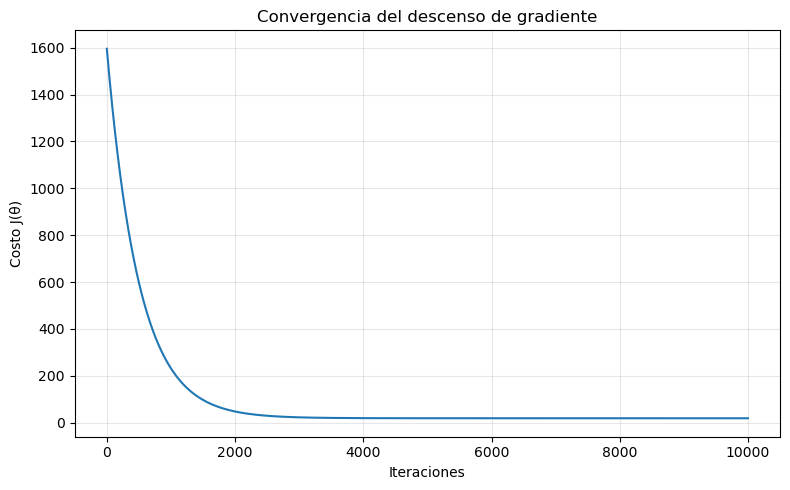

In [166]:
plt.figure(figsize=(8, 5))
plt.plot(costos)
plt.xlabel('Iteraciones')
plt.ylabel('Costo J(θ)')
plt.title('Convergencia del descenso de gradiente')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Coeficientes del modelo

Los coeficientes corresponden a las variables **normalizadas**.

In [167]:
nombres_theta = ['theta_0 (intercepto)'] + nombres_columnas

print('Coeficientes del modelo (primeros 15):')
print('-' * 50)
for nombre, valor in list(zip(nombres_theta, theta.flatten()))[:15]:
    print(f'{nombre:40s}: {valor:10.6f}')

print('...')
print(f'Total de parámetros: {len(nombres_theta)}')

Coeficientes del modelo (primeros 15):
--------------------------------------------------
theta_0 (intercepto)                    :  54.779845
Age                                     :   4.943248
Height_cm                               :  -0.326754
Weight_kg                               :   0.855708
BMI                                     :   0.698009
Blood_Pressure_Systolic                 :   4.241461
Blood_Pressure_Diastolic                :   2.480166
Heart_Rate                              :   0.050472
Blood_Glucose                           :   3.673694
HbA1c                                   :   2.985698
Total_Cholesterol                       :   2.464528
HDL                                     :  -1.222955
LDL                                     :   2.382406
Triglycerides                           :   1.731839
Smoking_Status                          :   2.416570
...
Total de parámetros: 63


## 10. Función auxiliar para predecir un registro

Aplica exactamente el mismo preprocesamiento usado en entrenamiento.

In [168]:
def preparar_entrada(registro, variables_x, mapeos_ordinales, columnas_binarias, columnas_onehot,
                     nombres_columnas, media, desviacion):
    """Prepara un único registro (Serie o dict) para el modelo."""
    # Convertir a DataFrame de una fila
    if isinstance(registro, pd.Series):
        entrada = registro[variables_x].to_frame().T
    else:
        entrada = pd.DataFrame([registro])[variables_x]

    # Ordinal encoding
    for columna, mapeo in mapeos_ordinales.items():
        if columna in entrada.columns:
            entrada[columna] = entrada[columna].map(mapeo)

    # Codificación binaria (Yes/No -> 1/0)
    for columna in columnas_binarias:
        if columna in entrada.columns:
            entrada[columna] = entrada[columna].map({'Yes': 1, 'No': 0})

    # One-hot encoding - usar las mismas columnas que en entrenamiento
    for col in columnas_onehot:
        if col in entrada.columns:
            entrada = pd.get_dummies(entrada, columns=[col], drop_first=True)

    # Alinear columnas con las del entrenamiento
    for col in nombres_columnas:
        if col not in entrada.columns:
            entrada[col] = 0
    entrada = entrada[nombres_columnas]

    # Normalizar
    entrada_norm = (entrada - media) / desviacion

    # Añadir intercepto
    entrada_modelo = np.r_[1, entrada_norm.to_numpy(dtype=float).flatten()].reshape(1, -1)
    return entrada_modelo


def predecir_riesgo(registro, theta, variables_x, mapeos_ordinales, columnas_binarias, columnas_onehot,
                    nombres_columnas, media, desviacion):
    """Devuelve la predicción de Stroke_Risk_Score para un registro."""
    x = preparar_entrada(
        registro, variables_x, mapeos_ordinales, columnas_binarias, columnas_onehot,
        nombres_columnas, media, desviacion
    )
    return float((x @ theta)[0, 0])

## 11. Ejemplo de predicción con un registro del dataset

In [169]:
indice = 2
registro_real = df.iloc[indice]

prediccion = predecir_riesgo(
    registro_real,
    theta,
    variables_x,
    mapeos_ordinales,
    columnas_binarias,
    columnas_onehot,  # Agregado
    nombres_columnas,
    media,
    desviacion
)

print(f'Registro índice: {indice}')
print(f'Riesgo de stroke real:     {registro_real["Stroke_Risk_Score"]}')
print(f'Riesgo de stroke predicho: {prediccion:.2f}')

Registro índice: 2
Riesgo de stroke real:     76
Riesgo de stroke predicho: 72.96


In [170]:
# Otro ejemplo
indice_ejemplo =4
registro_ejemplo = df.iloc[indice_ejemplo]

riesgo_pred = predecir_riesgo(
    registro_ejemplo,
    theta,
    variables_x,
    mapeos_ordinales,
    columnas_binarias,
    columnas_onehot,  # Agregado
    nombres_columnas,
    media,
    desviacion
)

print(f'Registro índice: {indice_ejemplo}')
print(f'Riesgo de stroke real:     {registro_ejemplo["Stroke_Risk_Score"]}')
print(f'Riesgo de stroke predicho: {riesgo_pred:.2f}')

Registro índice: 4
Riesgo de stroke real:     38
Riesgo de stroke predicho: 38.37
